# Flare Fitting with Bayesian model comparison

This tutorial introduces the flare fitting module for AltaiPony. It models stellar flares using analytic flare shapes from Davenport et al. (2014), combined with a polynomial baseline. The `find_flares()` detection results (`tstart`, `tstop`) are used to define the fitting regions, which are automatically expanded by a small time buffer to ensure full flare coverage. Each region may contain one or more overlapping flares. For each region, the model is optimized for different numbers of flares (1 to `max_flares`) using `emcee`.


**1. Load and Detrend the Light Curve** 

   - Load a light curve from TESS or Kepler using ``lightkurve.search_lightcurve()``
   - Convert to ``FlareLightCurve`` with ``to_flare_lightcurve``
   - Detrend with ``FlareLightCurve.detrend()``

**2. Detect Candidate Flares**

   - Detect flares using `find_flares()`
   - This generates an initial table of flare candidates with approximate parameters:
     - `tstart`, `tstop`: start and stop times of each candidate
     - `ampl_rec`, `ed_rec`: estimates of flare amplitude and equivalent duration
   - These parameters are refined using model fitting
   - It is advised to visually inspect whether the flare windows fully capture each event and exclude unrelated variability.

**3. Fit Flares**

   - Fit flare shapes with a composite model (polynomial baseline + analytic flares)
   - Evaluate model quality using BIC
   - Extract posterior uncertainties

**4. Build Summary Table**

   - Use `flare_table()` to construct the final flare parameter table from the best-fit models
   - This updates the preliminary `find_flares()` estimates with model-derived values and posterior errors

**5. Inspect Posterior Distributions**

  - Use `corner(index)` to plot the posterior distributions for a specific row in the flare table
  - `index` corresponds to the row number (e.g. `0` for the first row)
  - Automatically redirects to the group-level posterior if the row is a `group_member`

In [1]:
import matplotlib.pyplot as plt
from altaipony.lcio import to_flare_lightcurve
from altaipony.customdetrend import custom_detrending
import lightkurve as lk

arviz_base not installed
arviz_stats not installed
arviz_plots not installed


## 1. Load and detrend the light curve

2% (399/18699) of the cadences will be ignored due to the quality mask (quality_bitmask=175).
2% (399/18699) of the cadences will be ignored due to the quality mask (quality_bitmask=175).
/home/ilin/anaconda3/envs/altaidev/lib/python3.12/site-packages/altaipony/flarelc.py:465: UserWarning: Lightkurve doesn't allow columns or meta values to be created via a new attribute name.A new attribute is created. It will not be carried over when the object is copied. - see https://docs.lightkurve.org/reference/api/lightkurve.LightCurve.html
  lc.gaps = split_gaps(gaps, splits)


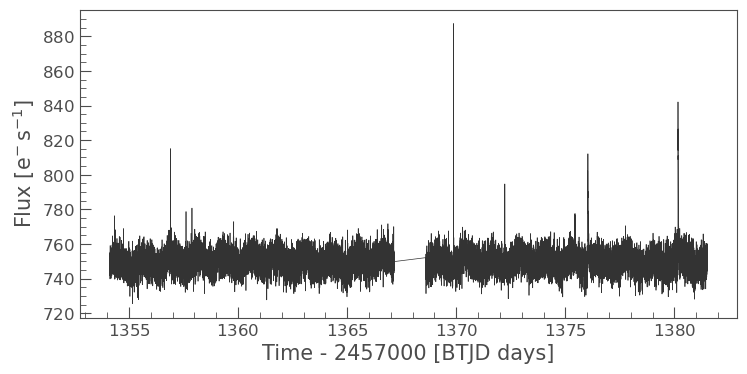

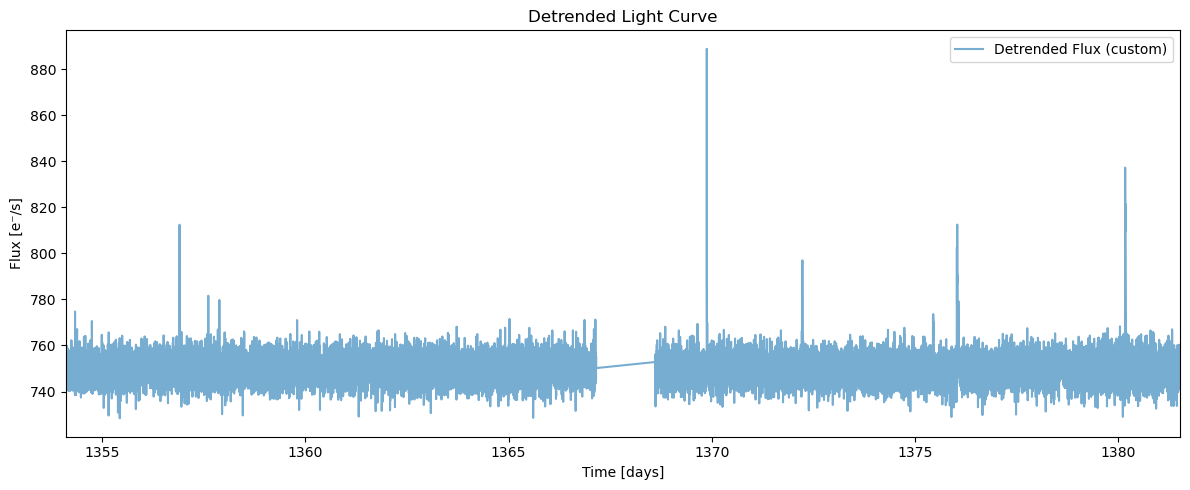

In [2]:
%matplotlib inline
lcs = lk.search_lightcurve("TIC 29780677", sector=2, exptime=120, mission="TESS", author="SPOC")
lc = lcs[0].download()
flc = to_flare_lightcurve(lc)

flc.plot()


flcd = flc.detrend("custom", func=custom_detrending)

plt.figure(figsize=(12, 5))

plt.plot(flcd.time.value, flcd.detrended_flux, label='Detrended Flux (custom)', alpha=0.6)
plt.xlim(flcd.time.value.min(), flcd.time.value.max())
plt.xlabel("Time [days]")
plt.ylabel("Flux [e⁻/s]")
plt.title("Detrended Light Curve")
plt.legend()
plt.tight_layout()
plt.show() 

## 2. Detect candidate flares

We use the built-in flare detection method via the `find_flares()`.

In [3]:
flcd = flcd.find_flares()
flcd.flares.sort_values(by="tstart", ascending=True)

Found 0 candidate(s) in the (0,9226) gap.
Found 5 candidate(s) in the (9226,18300) gap.
/home/ilin/anaconda3/envs/altaidev/lib/python3.12/site-packages/altaipony/altai.py:210: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lc.flares = pd.concat([lc.flares, new], ignore_index=True)


,istart,istop,cstart,cstop,tstart,tstop,ed_rec,ed_rec_err,ampl_rec,dur,total_n_valid_data_points
0,10142,10147,102541,102546,1369.874426,1369.881370,39.64047345332182,1.550517944619211,0.1860123872756958,0.006944,18300.0
1,14075,14078,106547,106550,1375.438284,1375.442450,9.999079783782921,1.582285247735526,0.031185507774353027,0.004167,18300.0
2,14483,14501,106969,106987,1376.024391,1376.049391,125.42034849312344,3.795862371473382,0.08412003517150879,0.025000,18300.0
3,14507,14512,106994,106999,1376.059113,1376.066057,20.210267995882976,2.0278452955304034,0.03974902629852295,0.006944,18300.0
4,17372,17388,109949,109965,1380.163246,1380.185468,135.29293779073834,3.724579600571005,0.11716091632843018,0.022222,18300.0


We now have:

1. A **detrended light curve** with reduced stellar variability, which improves flare detection.
2. A set of **flare candidates** identified using `find_flares()`.
3. A **preliminary table of flare properties**, including approximate times (`tstart`, `tstop`), amplitudes (`ampl_rec`), and equivalent durations (`ed_rec`, `ed_rec_err`).

These initial estimates will be refined through model fitting in the next step.

## 3. Visualize detected flares

After detecting flares with `find_flares()`, it is useful to visually inspect whether the detected regions (`tstart`, `tstop`) correctly enclose the flare events and do not include unrelated variability.

We plot the original and detrended light curves, with the flare regions highlighted using red spans. This helps verify that:
- The flare windows fully capture the flare peaks
- No flares were missed due to overly strict thresholds
- The detrending preserved flare morphology

We can also zoom in on an individual flare regions for detailed inspection.


/home/ilin/anaconda3/envs/altaidev/lib/python3.12/site-packages/altaipony/flarelc.py:687: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


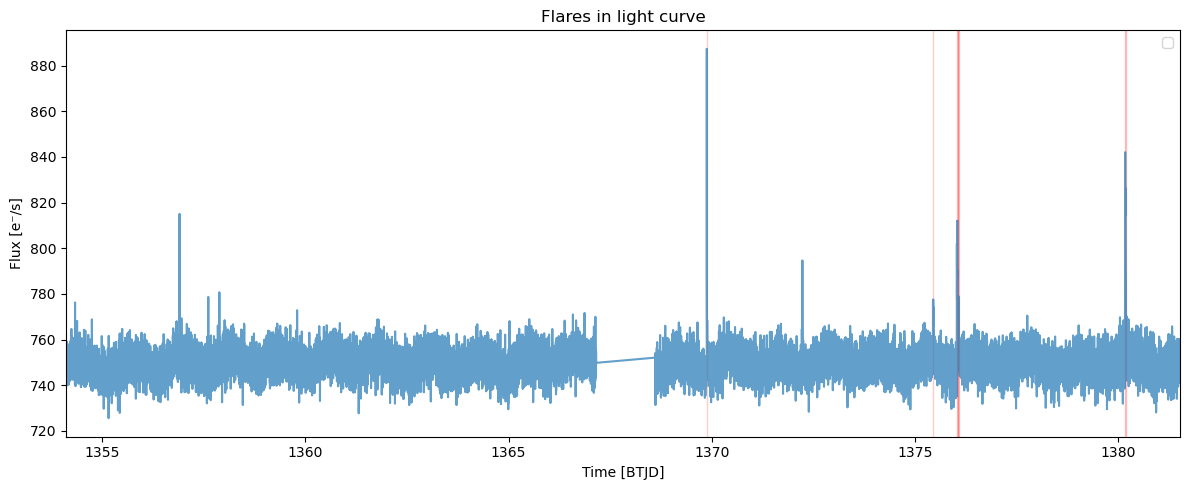

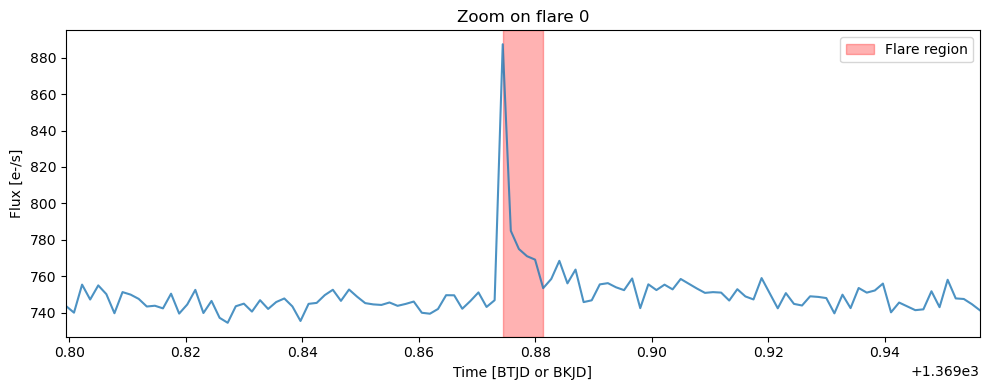

In [4]:

# Show all detected flares in the light curve
flcd.highlight_all_flares_in_lightcurve()

# Plot zoomed-in views of each detected flare
flcd.zoom_in_on_flare(0)


## 4. Fit flares

We now apply the flare fitting module to the flare regions detected by `find_flares()`. Each region is defined by a ``tstart``-``tstop`` pair, and is automatically expanded by a small time buffer cover the full flare and some quiescent flux. Regions that overlap or occur close together are grouped and fitted simultaneously.

The flare fitting function:
The `fit_flares()` function accepts several user-configurable arguments:

- `buffer`:  
  The time (in days) added before and after each flare detection window. This ensures the flare is not clipped at the edges and allows for a more stable baseline fit. A typical value is `0.05` (i.e., 72 minutes).

- `max_flares`:  
  The maximum number of flare components to attempt fitting in each region. The function will try all models from `n = 1` up to `n = max_flares` and select the best one based on BIC.

- `delta_bic`:  
  Minimum BIC improvement required to accept a more complex model.  
  This helps avoid overfitting by rejecting additional flares that do not significantly improve the fit.  
  **Example:** `delta_bic=2` means a model must improve BIC by at least 2 points to be accepted.

- `plot`:  
  If `True`, plots will be generated during fitting to show the best model per region.  
  **Recommended:** Turn it off when processing large numbers of flares.

- `debug_plot`:  
  If `True`, additional plots are shown for *all attempted models* in each region (e.g., for `n = 1`, `n = 2`, `n = 3`).  
  This is useful for understanding how BIC selects the optimal flare count, and for spotting overfitting or poor fits.  
  **Set to `False`** for normal use or large datasets, as this can produce a large number of plots.
  

 **Note: Detrending vs Fitting Input**

While the `find_flares()` function **requires** a detrended light curve to reliably detect flux enhancements due to flares, the flare fitting module (`fit_flares()`) is best applied to the **original, non-detrended** flux.

This is because detrending methods (e.g., Savitzky-Golay filters) can distort flare shapes by artificially modifying the baseline near flare events.



 Fitting region from 1369.82443 to 1369.93137; Region [0](max. number of flares in group = 3 x 1)


  0%|          | 0/1000 [00:00<?, ?it/s]/home/ilin/anaconda3/envs/altaidev/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 1000/1000 [00:06<00:00, 146.41it/s]


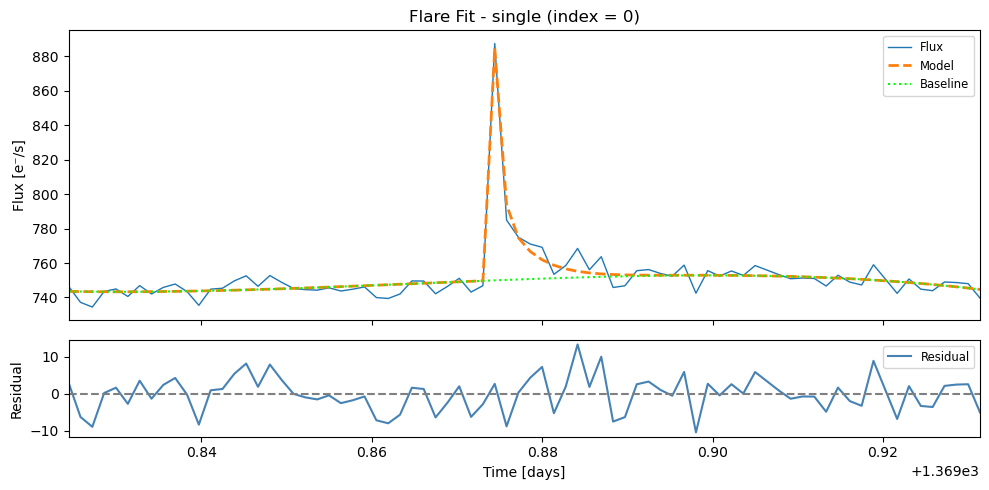


 Fitting region from 1375.38828 to 1375.49245; Region [1](max. number of flares in group = 3 x 1)


100%|██████████| 1000/1000 [00:05<00:00, 169.62it/s]


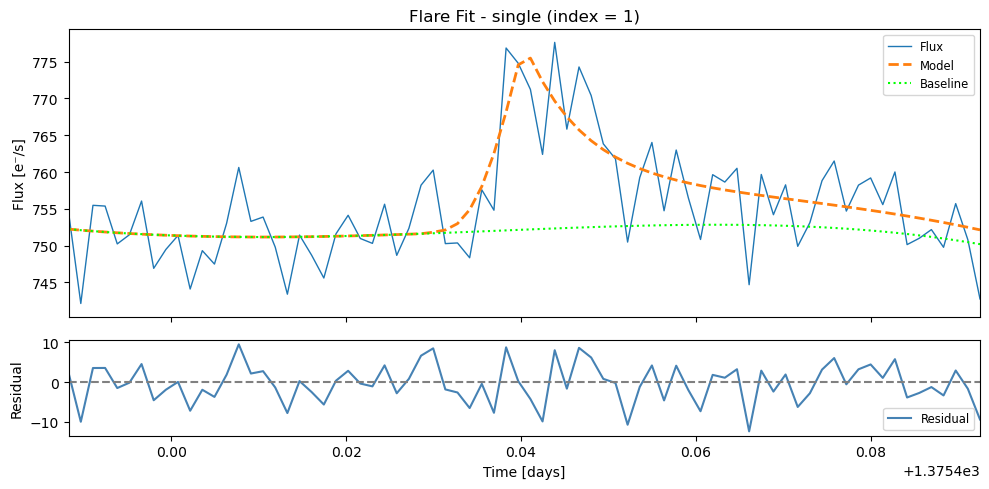


 Fitting region from 1375.97439 to 1376.11606; Region [2](max. number of flares in group = 3 x 2)


100%|██████████| 1000/1000 [00:14<00:00, 67.31it/s]


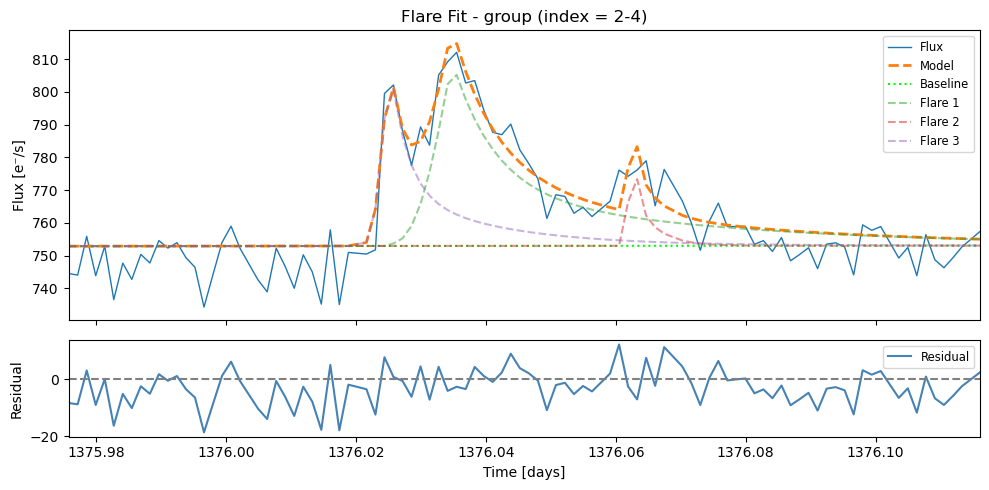


 Fitting region from 1380.11325 to 1380.23547; Region [3](max. number of flares in group = 3 x 1)


100%|██████████| 1000/1000 [00:08<00:00, 111.12it/s]


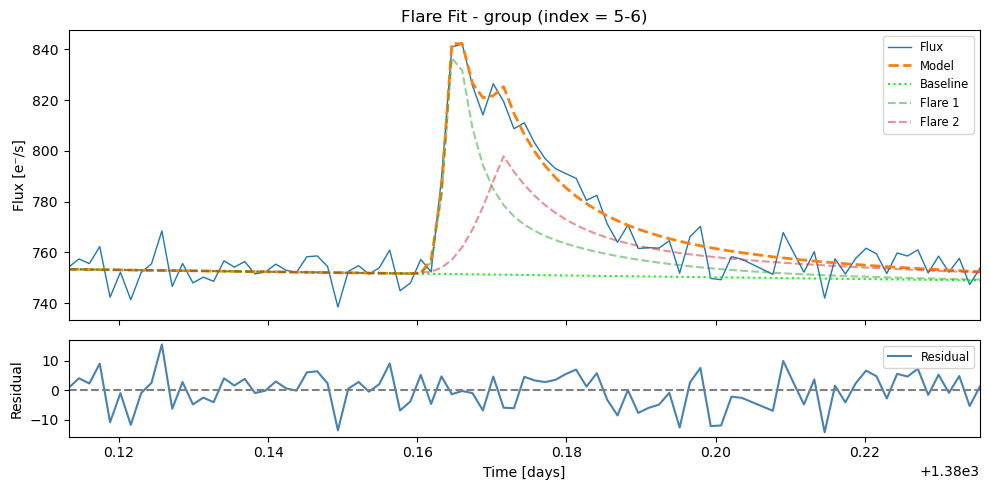

In [5]:
fit = flcd.fit_flares(
    buffer=0.05,          # Add ±0.05 buffer before/after each flare region for safe margin
    max_flares=3,         # Test models with 1–3 flares per region
    delta_bic=2.0,        # Only accept a more complex model if BIC improves by at least 2 points
    plot=True,            # Plot only the best fit for each region
    debug_plot=False,      # Suppress intermediate trial fits (e.g. for n = 1, 2, 3)
    n_steps = 1000,       # Number of MCMC steps per walker
    nwalkers = 30        # Number of MCMC walkers
)

We compile all results into a summary table that lists the properties of each detected and fitted flare. This is done using `flare_table()`, which extracts key parameters from the results list.


In [6]:
results = flcd.flare_table(fit)
display(results)

,t_peak,t_peak_err,fwhm,fwhm_err,amplitude,amplitude_err,ed_rec,fit_type,group_index
0,1369.874236,0.000186,0.002079,0.000380,167.845753,38.897515,40.569280,single,
1,1375.440324,0.001245,0.020979,0.014082,25.494519,5.062015,47.499385,single,
2,1376.034817,0.000523,0.020652,0.004911,56.981779,2.788231,114.989007,group_member,1
3,1376.062320,0.002079,0.001861,0.000690,56.679205,2.024237,9.704213,group_member,1
4,1376.025111,0.000330,0.008403,0.002151,57.934381,1.463386,50.602447,group_member,1
5,1380.165053,0.000168,0.008693,0.001366,104.560765,11.672021,94.604672,group_member,2
6,1380.171531,0.000849,0.023346,0.005365,47.265332,7.699650,100.990722,group_member,2


**Notes**

- `ed_rec`: The equivalent duration values in the table are derived from the best-fit analytic flare model, rather than by directly summing the observed flux within the `tstart`-`tstop` detection window. This model-based approach provides more estimates that are less sensitive to noise, outliers, or the exact placement of the detection window. However, it also means that the ED values are **dependent on the shape defined by the flare model.**

- `fit_type` indicates the context of the fit:
  - `"single"`: the flare was fit individually (no nearby overlapping events)
  - `"group"`: the combined fit of a group of overlapping flares
  - `"group_member"`: a single flare extracted from a group fit

- `group_index` gives the ID of each flare group (1, 2, 3, ...). All flares sharing the same group index were modeled together. The group row (if present) summarizes the overall multi-flare fit, while the `group_member` rows list the individual flares. You can get the group-wise solution by adding the keyword argument ``include_group_rows=True`` in ``flare_table()``.


## 5. Inspect posterior distributions

The `corner()` function displays the posterior distributions of the flare model parameters for a selected row in the flare table. This helps assess the uncertainty and correlation structure of the fitted values.

To use it, pass the index of the row you want to inspect:

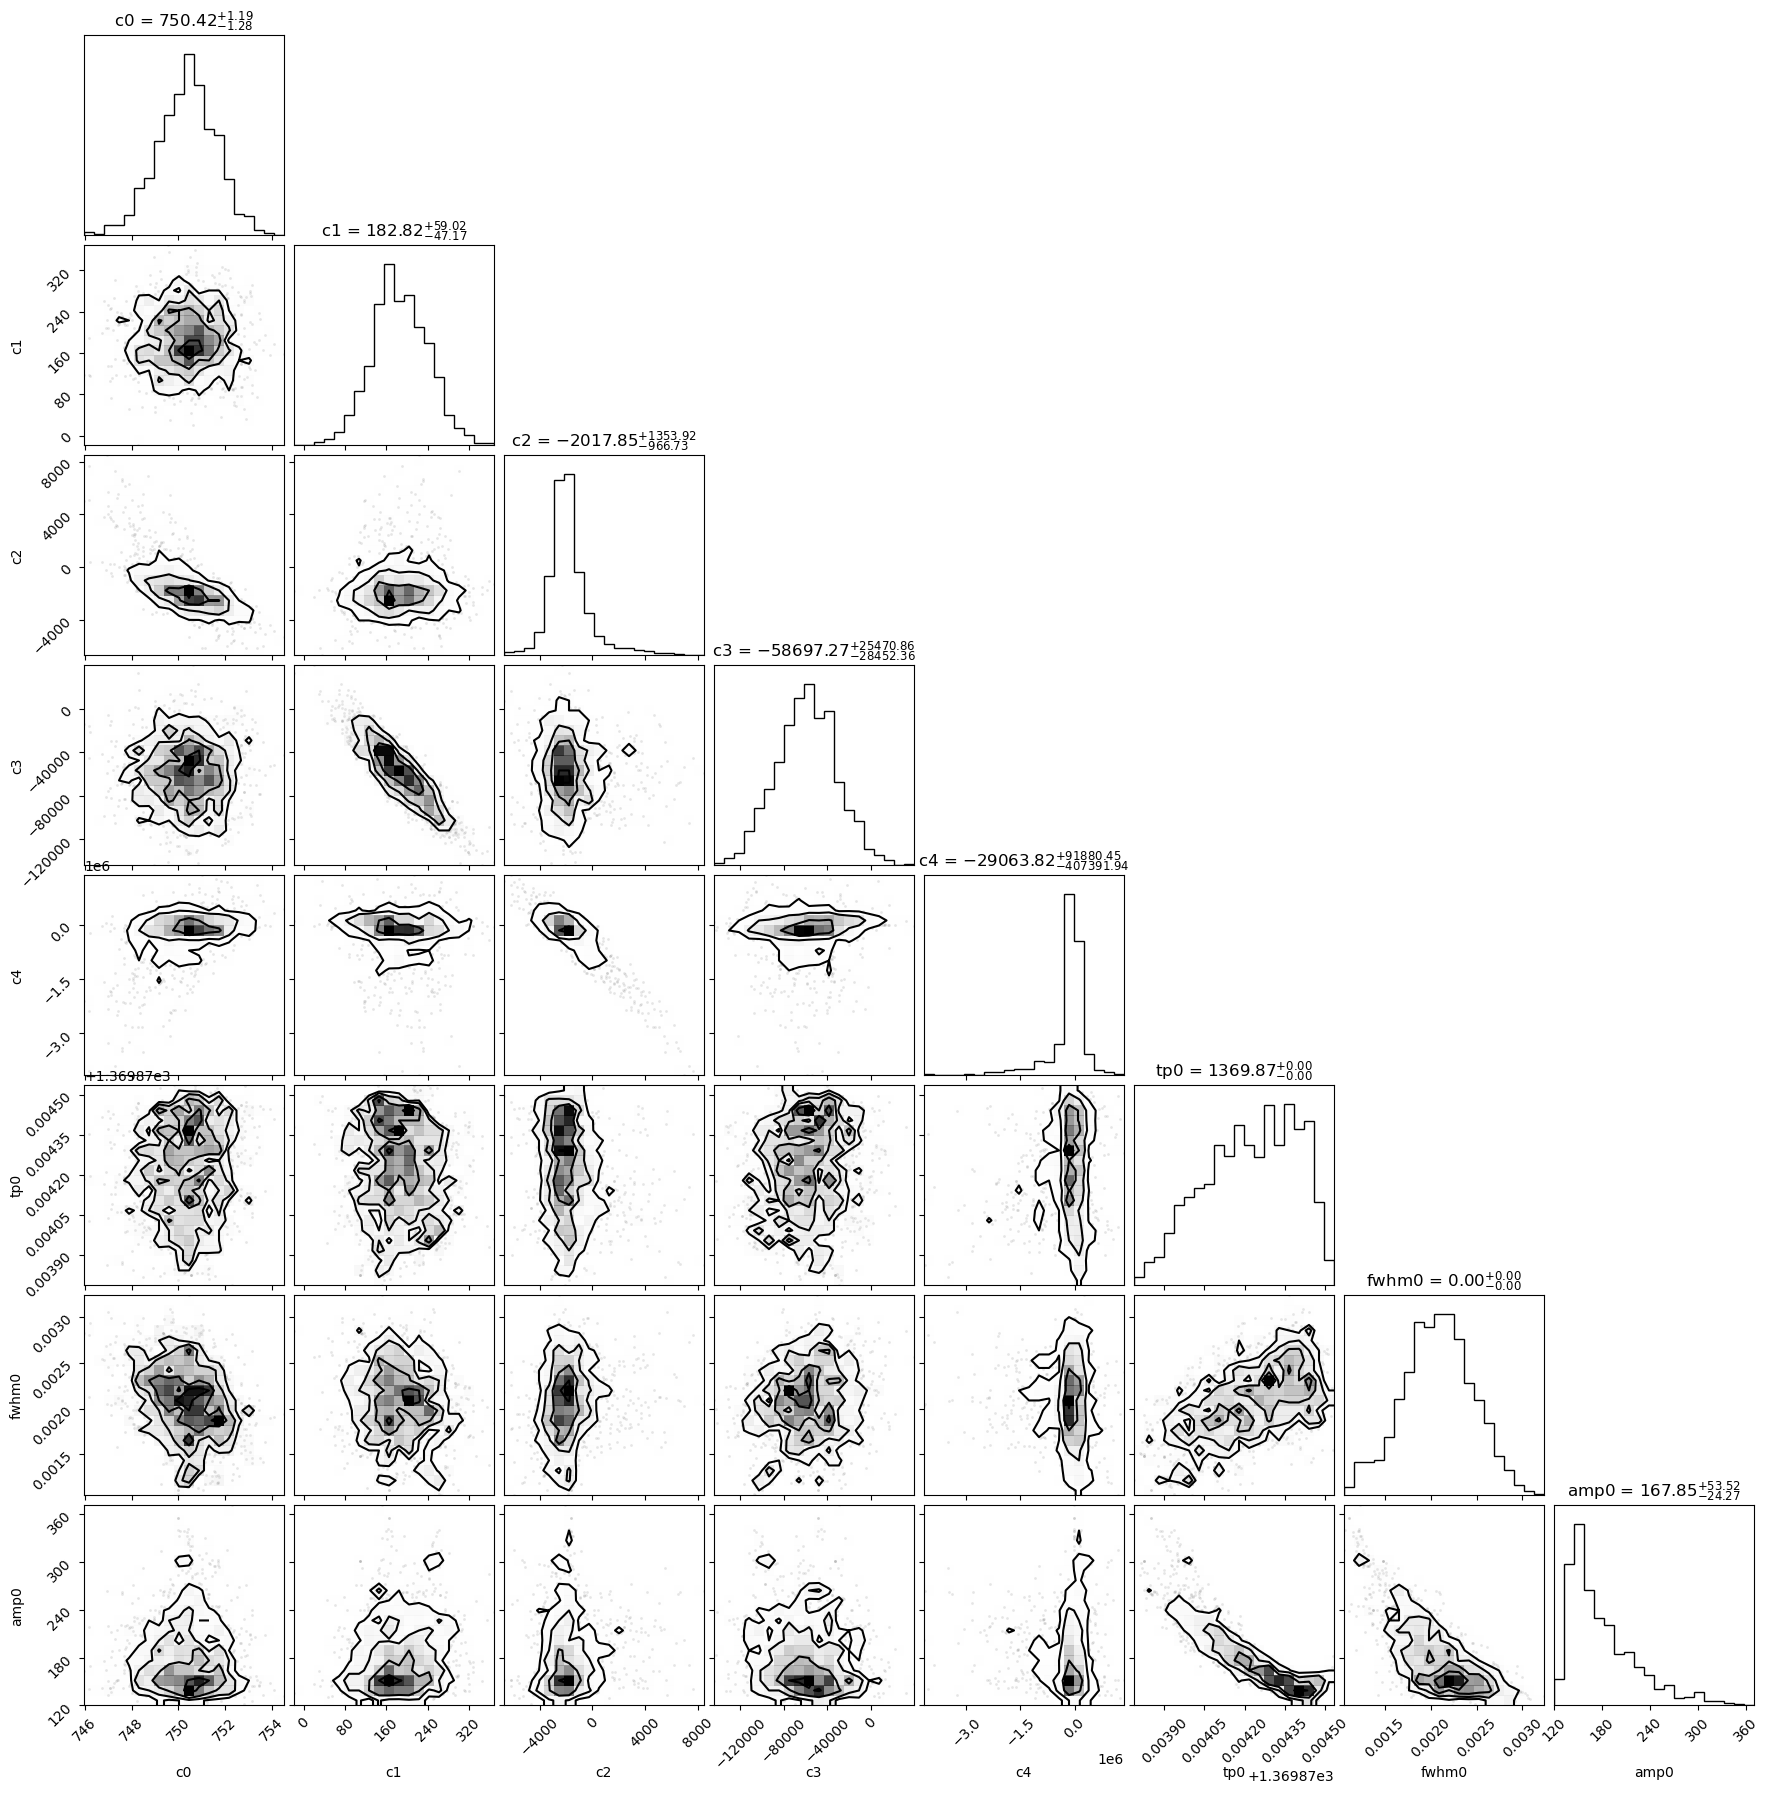

In [7]:
flcd.corner(0)

This shows a corner plot for the flare fit in row 0 of the table. If the selected row corresponds to a `group_member`, the method automatically loads the full posterior from the associated group fit.

The plot includes:

* `c0–c4`: coefficients of the 4th-order baseline polynomial

* `tp{i}`: peak times of each fitted flare

* `fwhm{i}`: flare widths

* `amp{i}`: flare amplitudes

This can be used to verify that parameters are well-constrained and to explore any potential degeneracies between model components.